In [1]:
import georinex as gr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings

# غیرفعال کردن هشدارهای مزاحم
warnings.filterwarnings('ignore')

pd.set_option('display.max_rows', 10)
pd.set_option('display.max_columns', 10)
pd.set_option('display.width', 120)

obs_file = 'tehn0600.17o'

try:
    obs = gr.load(obs_file)
    
    df = obs.to_dataframe()
    df.dropna(how='all', inplace=True)
    
    # اصلاح: استخراج نام مشاهدات از متغیرهای دیتاست
    obs_list = list(obs.data_vars)
    print("انواع مشاهدات موجود:")
    print(obs_list)
    print("-----------------------------------------")

    print("نمونه‌ای از داده‌های استخراج شده:")
    print(df.reset_index().head())
    print("-----------------------------------------")

    sv_id = 'G01'
    if sv_id in df.index.get_level_values('sv'):
        print(f"مشاهدات برای ماهواره {sv_id}:")
        sv_data = df.loc[pd.IndexSlice[:, sv_id], :]
        # ممکن است نام مشاهدات در فایل شما C1 و L1 باشد، اگر C1C خطای ستون داد، آن را به C1 و L1 تغییر دهید
        available_cols = [col for col in ['C1', 'L1', 'C1C', 'L1C', 'P1', 'P2'] if col in sv_data.columns]
        print(sv_data[available_cols].head())
    else:
        print(f"ماهواره {sv_id} در داده‌ها یافت نشد.")

except Exception as e:
    print(f"خطا: {e}")

# df


انواع مشاهدات موجود:
['L1', 'L2', 'C1', 'C2', 'P2', 'D1', 'D2', 'S1', 'S2']
-----------------------------------------
نمونه‌ای از داده‌های استخراج شده:
        time   sv            L1            L2            C1  ...            P2  D1  D2    S1    S2
0 2017-03-01  G10  1.095906e+08  8.539530e+07  2.085439e+07  ...  2.085440e+07 NaN NaN  51.7  49.8
1 2017-03-01  G15  1.201571e+08  9.362892e+07  2.286513e+07  ...  2.286514e+07 NaN NaN  47.8  39.6
2 2017-03-01  G16  1.217323e+08  9.485639e+07  2.316490e+07  ...  2.316490e+07 NaN NaN  45.9  28.6
3 2017-03-01  G18  1.082538e+08  8.435353e+07  2.059999e+07  ...  2.059999e+07 NaN NaN  45.6  37.6
4 2017-03-01  G20  1.263418e+08  9.844836e+07  2.404209e+07  ...  2.404209e+07 NaN NaN  38.9  19.6

[5 rows x 11 columns]
-----------------------------------------
مشاهدات برای ماهواره G01:
                                   C1            L1            P2
time                sv                                           
2017-03-01 02:22:00 G01  2.4548

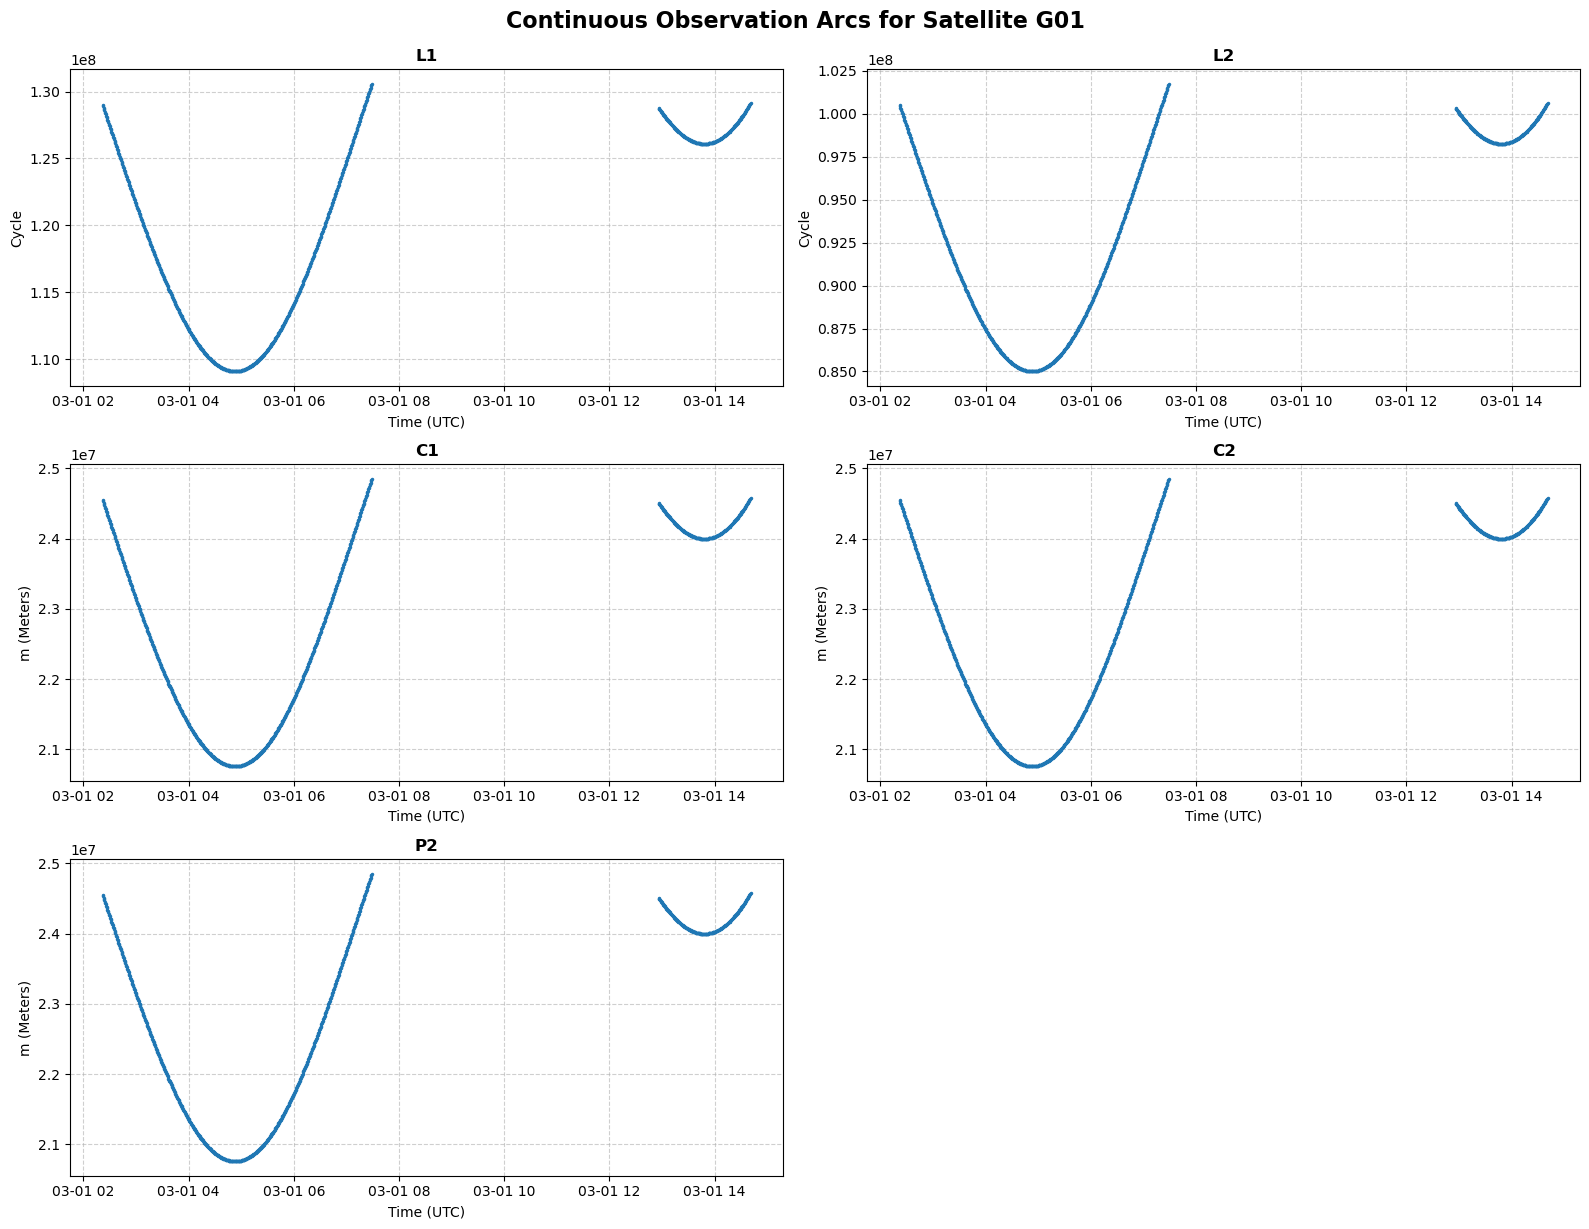

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

sv_id = 'G01'

if sv_id in df.index.get_level_values('sv'):
    # استخراج داده‌های مربوط به ماهواره مورد نظر
    sv_data = df.loc[pd.IndexSlice[:, sv_id], :]
    times = sv_data.index.get_level_values('time')
    
    # لیستی از مشاهداتی که می‌خواهیم رسم کنیم
    # دقت کنید که نام ستون‌ها باید با نام‌های موجود در دیتافریم شما همخوانی داشته باشد
    observations = ['L1', 'L2', 'C1', 'C2', 'P2']
    
    # ایجاد یک قاب با گرید 3 سطر و 2 ستون
    fig, axes = plt.subplots(3, 2, figsize=(16, 12))
    axes = axes.flatten() # تبدیل آرایه دو بعدی محورها به یک بعدی برای دسترسی آسان‌تر
    
    for i, obs in enumerate(observations):
        ax = axes[i]
        
        if obs in sv_data.columns:
            # رسم داده‌ها با استفاده از مارکر نقطه (برای عدم اتصال شکاف‌ها)
            ax.plot(times, sv_data[obs], '.', markersize=3, color='#1f77b4')
            
            ax.set_title(f'{obs}', fontweight='bold')
            ax.grid(True, linestyle='--', alpha=0.6)
            
            # تنظیم لیبل محور Y متناسب با نوع مشاهده (فاز یا کد)
            if obs.startswith('L'):
                ax.set_ylabel('Cycle')
            else:
                ax.set_ylabel('m (Meters)')
                
            ax.set_xlabel('Time (UTC)')
            
            # استفاده از نماد علمی برای محور Y به دلیل بزرگ بودن مقادیر
            ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
        else:
            # اگر ستون مشاهده در دیتافریم موجود نبود
            ax.text(0.5, 0.5, f'Data for {obs} not found', 
                    horizontalalignment='center', verticalalignment='center', 
                    transform=ax.transAxes, fontsize=12, color='red')
            ax.set_title(f'{obs}')
            ax.set_axis_off()

    # حذف کردن ساب‌پلات ششم (خالی) از شکل
    fig.delaxes(axes[5])
    
    # تنظیم فاصله مناسب بین نمودارها
    plt.tight_layout()
    fig.suptitle(f'Continuous Observation Arcs for Satellite {sv_id}', fontsize=16, fontweight='bold', y=1.02)
    
    plt.show()
else:
    print(f"داده‌ای برای ماهواره {sv_id} یافت نشد.")


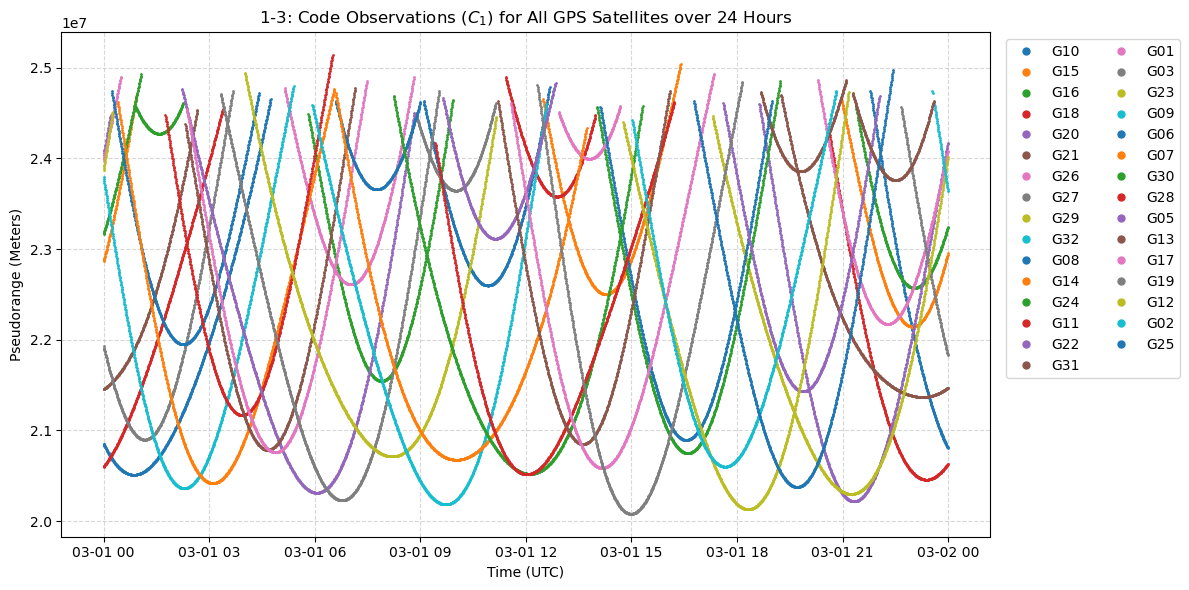

In [3]:

plt.figure(figsize=(12, 6))

# استخراج لیست تمام ماهواره‌های یکتای موجود در دیتافریم
all_svs = df.index.get_level_values('sv').unique()

# حلقه برای رسم داده‌های هر ماهواره
for sv in all_svs:
    # فقط ماهواره‌های GPS (حرف G) را رسم می‌کنیم تا نمودار خیلی شلوغ نشود
    if sv.startswith('G'):
        sv_data = df.loc[pd.IndexSlice[:, sv], :]
        times = sv_data.index.get_level_values('time')
        
        # در صورت وجود C1 آن را رسم می‌کنیم
        if 'C1' in sv_data.columns:
            # از رسم نقطه‌ای استفاده می‌کنیم تا آرک‌ها تمیز در بیایند
            plt.plot(times, sv_data['C1'], '.', markersize=2, label=sv)

plt.title('1-3: Code Observations ($C_1$) for All GPS Satellites over 24 Hours')
plt.xlabel('Time (UTC)')
plt.ylabel('Pseudorange (Meters)')

# تنظیمات نمایش
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.grid(True, linestyle='--', alpha=0.5)

# راهنمای نمودار در بیرون کادر قرار داده می‌شود تا روی نمودار را نپوشاند
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', markerscale=5, ncol=2)
plt.tight_layout()
plt.show()


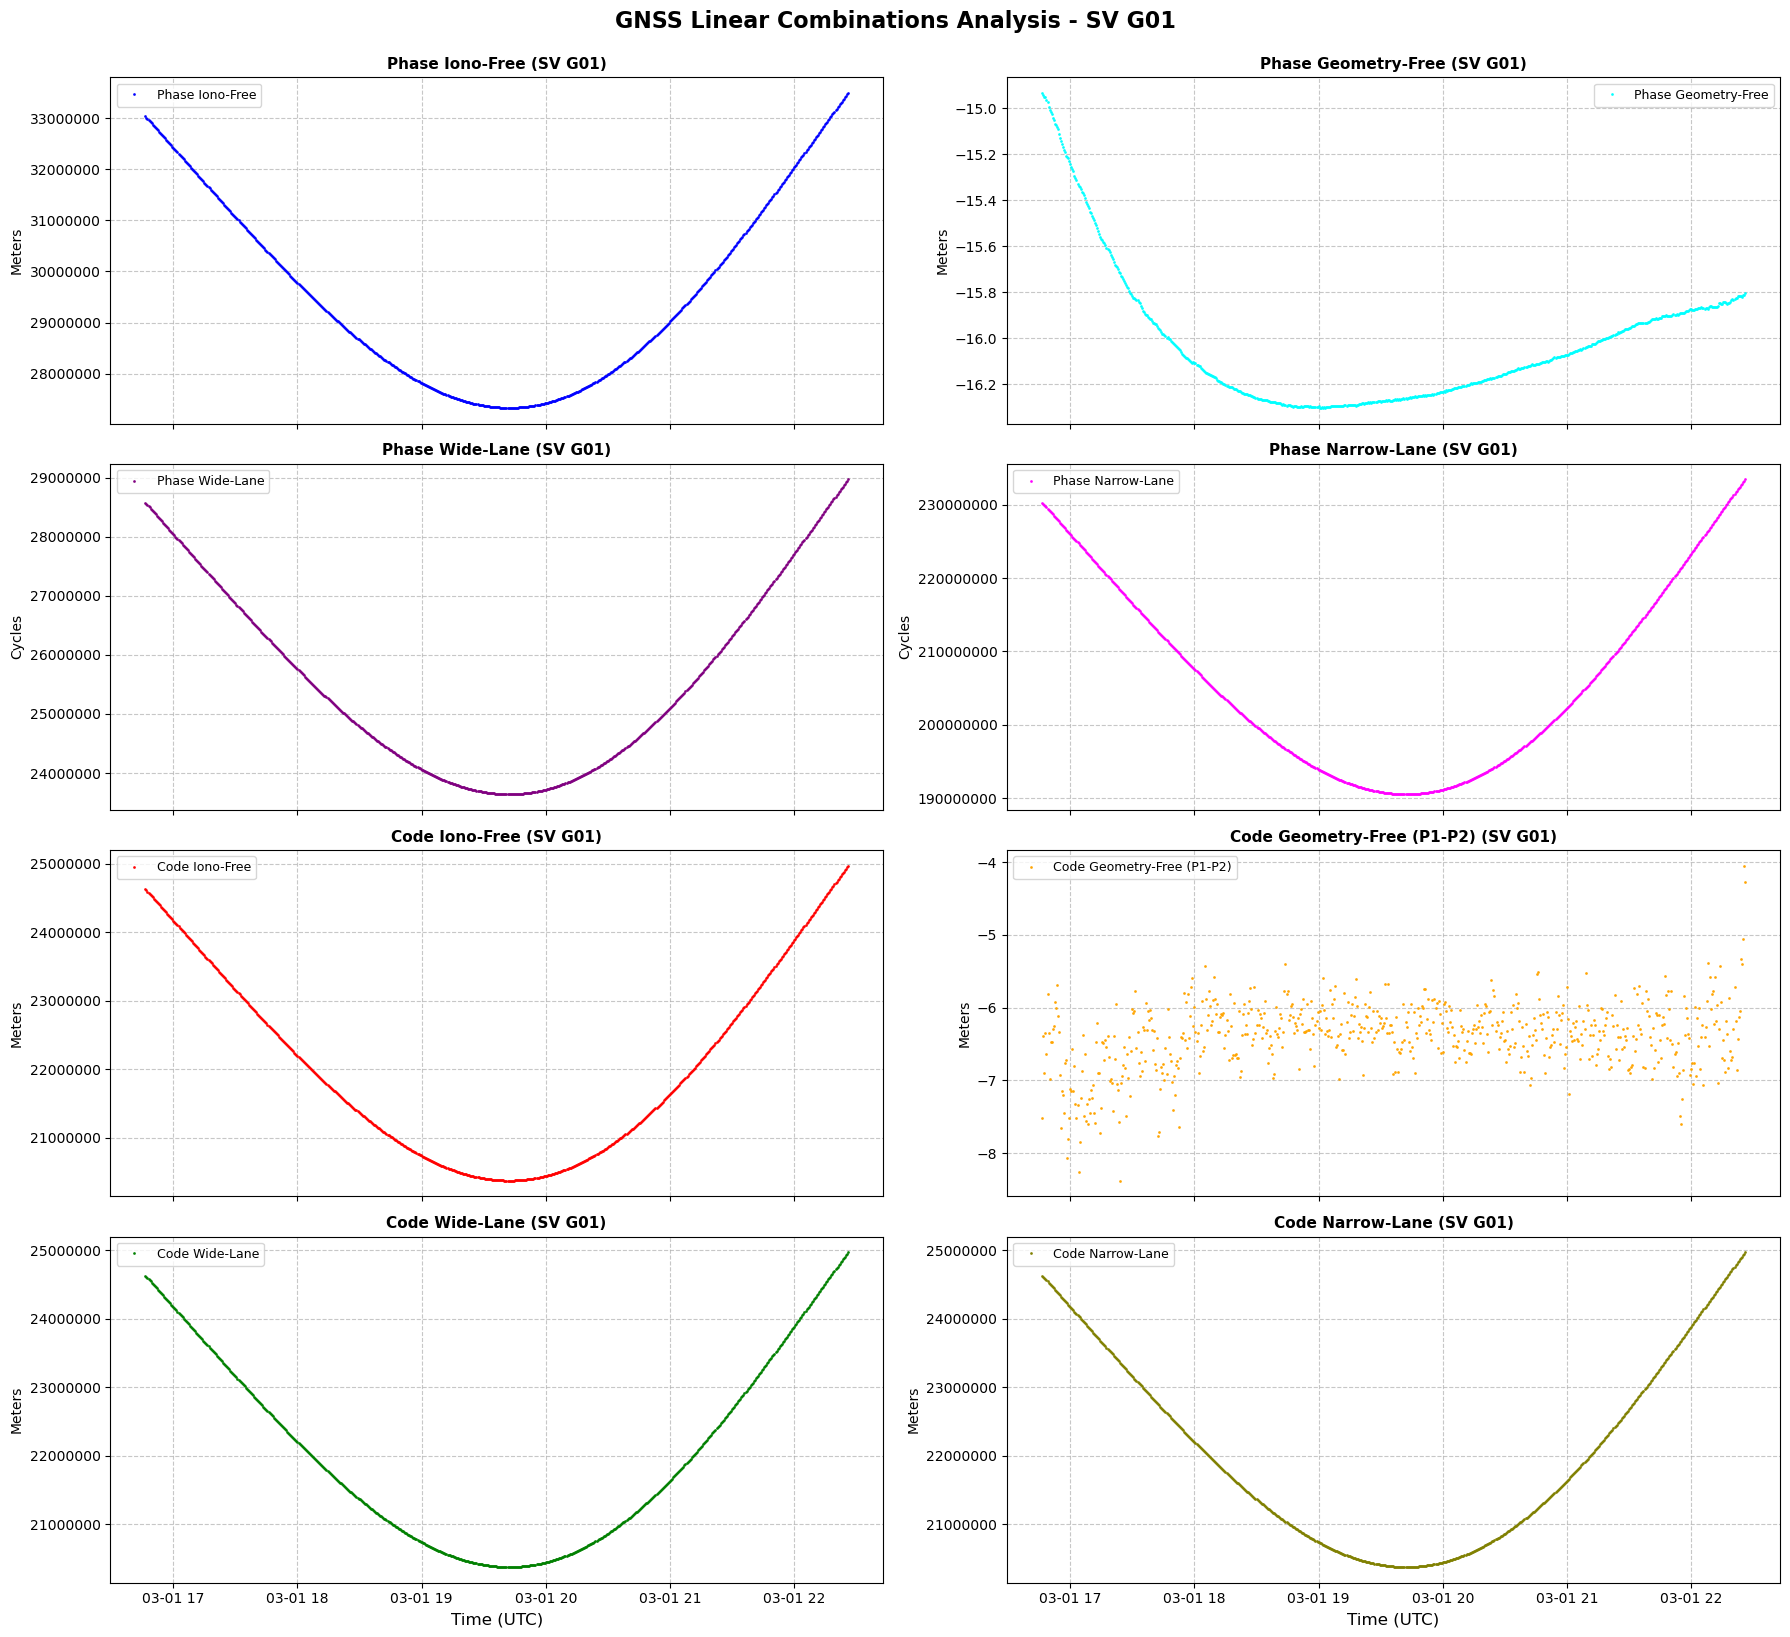

In [4]:
import matplotlib.pyplot as plt

# (ادامه کدهای قبلی... فرض می‌کنیم sv_data استخراج شده است)

if 'sv_data' in locals() and not sv_data.empty:
    # --- یافتن ستون‌های فاز ---
    L1_col = 'L1' if 'L1' in sv_data.columns else ('L1C' if 'L1C' in sv_data.columns else None)
    L2_col = 'L2' if 'L2' in sv_data.columns else ('L2W' if 'L2W' in sv_data.columns else ('L2P' if 'L2P' in sv_data.columns else None))
    
    # --- یافتن ستون‌های کد (شبه فاصله) ---
    C1_col = 'C1' if 'C1' in sv_data.columns else ('P1' if 'P1' in sv_data.columns else None)
    C2_col = 'P2' if 'P2' in sv_data.columns else ('C2' if 'C2' in sv_data.columns else None)
    
    if L1_col and L2_col and C1_col and C2_col:
        L1 = sv_data[L1_col]
        L2 = sv_data[L2_col]
        P1 = sv_data[C1_col]
        P2 = sv_data[C2_col]
        
        # فرکانس‌های GPS به هرتز
        f1 = 1575.42e6
        f2 = 1227.60e6
        
        # ضرایب ترکیب Ionosphere-Free
        alpha = (f1**2) / (f1**2 - f2**2)
        beta = (f2**2) / (f1**2 - f2**2)
        
        # ==========================================
        # سرعت نور در خلأ (متر بر ثانیه)
        c = 299792458.0 

        # طول موج‌ها
        lambda1 = c / f1
        lambda2 = c / f2

        # ==========================================
        # محاسبات اصلاح شده ترکیبات فاز (Phase)
        # ==========================================
        sv_data['Phase_WideLane'] = L1 - L2 # در واحد سیکل صحیح است
        sv_data['Phase_NarrowLane'] = L1 + L2 # در واحد سیکل صحیح است
        sv_data['Phase_IonoFree'] = (alpha *lambda1* L1) - (beta *lambda1* L2) # در واحد سیکل

        # تبدیل فاز به متر برای حذف فاصله هندسی
        sv_data['Phase_GeoFree'] = (lambda1 * L1) - (lambda2 * L2) # واحد: متر

                # ==========================================
        # محاسبات ترکیبات برای مشاهدات کد (Code/Pseudorange)
        # ==========================================
        sv_data['Code_WideLane'] = (f1 * P1 - f2 * P2) / (f1 - f2)
        sv_data['Code_NarrowLane'] = (f1 * P1 + f2 * P2) / (f1 + f2)
        sv_data['Code_IonoFree'] = (alpha * P1) - (beta * P2)
        sv_data['Code_GeoFree'] = P1 - P2
        


# (فرض می‌شود محاسبات sv_data از قبل انجام شده است)

if 'sv_data' in locals() and not sv_data.empty:
    
    # ایجاد یک پنجره رسم با 8 زیرنمودار (4 سطر و 2 ستون)
    fig, axes = plt.subplots(4, 2, figsize=(18, 16), sharex=True)
    time_vals = sv_data.index.get_level_values('time')

    # یک دیکشنری برای تنظیمات ظاهری هر نمودار
    plots_config = [
        # سطر اول
{'ax': axes[0, 0], 'data': sv_data['Phase_IonoFree'], 'title': 'Phase Iono-Free', 'color': 'blue', 'ylabel': 'Meters'}, 
        {'ax': axes[0, 1], 'data': sv_data['Phase_GeoFree'], 'title': 'Phase Geometry-Free', 'color': 'cyan', 'ylabel': 'Meters'},
        
        # سطر دوم
        {'ax': axes[1, 0], 'data': sv_data['Phase_WideLane'], 'title': 'Phase Wide-Lane', 'color': 'purple', 'ylabel': 'Cycles'},
        {'ax': axes[1, 1], 'data': sv_data['Phase_NarrowLane'], 'title': 'Phase Narrow-Lane', 'color': 'magenta', 'ylabel': 'Cycles'},
        
        # سطر سوم
        {'ax': axes[2, 0], 'data': sv_data['Code_IonoFree'], 'title': 'Code Iono-Free', 'color': 'red', 'ylabel': 'Meters'},
        {'ax': axes[2, 1], 'data': sv_data['Code_GeoFree'], 'title': 'Code Geometry-Free (P1-P2)', 'color': 'orange', 'ylabel': 'Meters'},
        
        # سطر چهارم
        {'ax': axes[3, 0], 'data': sv_data['Code_WideLane'], 'title': 'Code Wide-Lane', 'color': 'green', 'ylabel': 'Meters'},
        {'ax': axes[3, 1], 'data': sv_data['Code_NarrowLane'], 'title': 'Code Narrow-Lane', 'color': 'olive', 'ylabel': 'Meters'}
    ]

    # رسم نمودارها
    for config in plots_config:
        ax = config['ax']
        # *** تغییر مهم: استفاده از marker='.' و linestyle='none' برای حذف خطوط بین گپ‌ها ***
        ax.plot(time_vals, config['data'], label=config['title'], 
                color=config['color'], marker='.', linestyle='none', markersize=2, alpha=0.9)
        
        # تنظیمات ظاهری هر زیرنمودار
        ax.set_title(f"{config['title']} (SV {sv_id})", fontsize=11, fontweight='bold')
        ax.set_ylabel(config['ylabel'], fontsize=10)
        ax.legend(loc='best', fontsize=9)
        ax.grid(True, linestyle='--', alpha=0.7)
        ax.ticklabel_format(useOffset=False, style='plain', axis='y') # جلوگیری از نمایش علمی

    # تنظیم لیبل محور X فقط برای سطر آخر
    axes[3, 0].set_xlabel('Time (UTC)', fontsize=12)
    axes[3, 1].set_xlabel('Time (UTC)', fontsize=12)

    # تنظیم فاصله بین نمودارها
    plt.tight_layout()
    
    # عنوان کلی برای کل پنجره
    fig.suptitle(f'GNSS Linear Combinations Analysis - SV {sv_id}', fontsize=16, fontweight='bold', y=1.02)
    
    plt.show()




In [5]:

def find_best_satellite_pair(file1, file2, obs_type='C1'):
    print("Loading RINEX files...")
    obs1 = gr.load(file1)
    obs2 = gr.load(file2)
    
    # 1. یافتن ماهواره‌های مشترک در هر دو فایل
    sats1 = set(obs1.sv.values)
    sats2 = set(obs2.sv.values)
    common_sats = sats1.intersection(sats2)
    
    # 2. یافتن زمان‌های دید مشترک برای هر ماهواره به تنهایی در هر دو ایستگاه
    sat_mutual_times = {}
    for sv in common_sats:
        try:
            t1 = obs1.sel(sv=sv)[obs_type].dropna(dim='time').time.values
            t2 = obs2.sel(sv=sv)[obs_type].dropna(dim='time').time.values
            sat_mutual_times[sv] = np.intersect1d(t1, t2)
        except KeyError:
            continue

    # 3. بررسی تمامی جفت ماهواره‌ها برای یافتن همزمان‌ترین دیدها
    max_overlap = 0
    best_pair = (None, None)
    valid_sats = list(sat_mutual_times.keys())
    
    for i in range(len(valid_sats)):
        for j in range(i+1, len(valid_sats)):
            sv1 = valid_sats[i]
            sv2 = valid_sats[j]
            
            # اشتراک زمانی دو ماهواره (یعنی زمان‌هایی که هر دو ماهواره در هر دو ایستگاه دیده می‌شوند)
            overlap = np.intersect1d(sat_mutual_times[sv1], sat_mutual_times[sv2])
            
            if len(overlap) > max_overlap:
                max_overlap = len(overlap)
                best_pair = (sv1, sv2)
                
    return best_pair, max_overlap

# اجرا
best_pair, epochs = find_best_satellite_pair('tehn0600.17o', 'bhr40600.17o')
print(f"Best Pair: {best_pair} with {epochs} common epochs.")


Loading RINEX files...
Best Pair: ('G21', 'G18') with 727 common epochs.


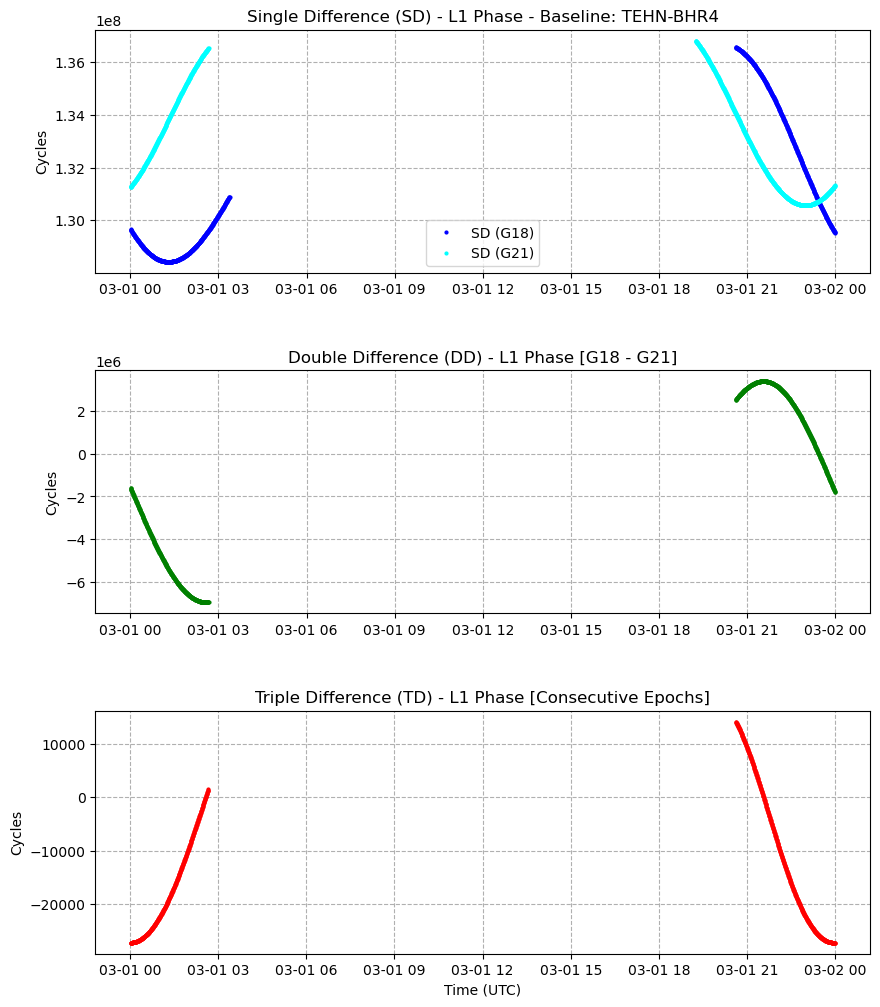

In [6]:

# ۱. بارگذاری فایل‌های راینکس (فقط خواندن ماهواره‌های مد نظر برای افزایش سرعت)
sats = list(best_pair)
obs_tehn = gr.load('tehn0600.17o').sel(sv=sats)
obs_bhr  = gr.load('bhr40600.17o').sel(sv=sats)

# ۲. پیدا کردن زمان‌های مشترک بین دو گیرنده
common_time = np.intersect1d(obs_tehn.time.values, obs_bhr.time.values)
tehn_c = obs_tehn.sel(time=common_time)
bhr_c  = obs_bhr.sel(time=common_time)

# استخراج مشاهدات فاز L1
L1_tehn = tehn_c['L1']
L1_bhr  = bhr_c['L1']

# ۳. محاسبه تفاضل یگانه (SD) بین دو ایستگاه برای هر ماهواره
# فرمول: SD = Obs_Tehn - Obs_Bhr
SD_G18 = L1_tehn.sel(sv='G18') - L1_bhr.sel(sv='G18')
SD_G21 = L1_tehn.sel(sv='G21') - L1_bhr.sel(sv='G21')

# ۴. محاسبه تفاضل دوگانه (DD) بین دو ماهواره G18 و G21
# در اینجا G21 را به عنوان ماهواره مرجع در نظر می‌گیریم
# فرمول: DD = SD_G18 - SD_G21
DD = SD_G18 - SD_G21

# ۵. محاسبه تفاضل سه‌گانه (TD) در زمان‌های متوالی
# فرمول: TD = DD(t2) - DD(t1)
TD = np.diff(DD.values)
time_TD = common_time[1:] # زمان برای TD یک اپک کمتر است

# ==========================================
# رسم نمودارها
# ==========================================
fig, axs = plt.subplots(3, 1, figsize=(10, 12), sharex=False)
plt.subplots_adjust(hspace=0.4)

# نمودار تفاضل یگانه (SD)
axs[0].plot(common_time, SD_G18, '.', markersize=4, label='SD (G18)', color='blue')
axs[0].plot(common_time, SD_G21, '.', markersize=4, label='SD (G21)', color='cyan')
axs[0].set_title('Single Difference (SD) - L1 Phase - Baseline: TEHN-BHR4')
axs[0].set_ylabel('Cycles')
axs[0].legend()
axs[0].grid(True, linestyle='--')

# نمودار تفاضل دوگانه (DD)
axs[1].plot(common_time, DD, '.', markersize=4, color='green')
axs[1].set_title('Double Difference (DD) - L1 Phase [G18 - G21]')
axs[1].set_ylabel('Cycles')
axs[1].grid(True, linestyle='--')

# نمودار تفاضل سه‌گانه (TD)
axs[2].plot(time_TD, TD, '.', markersize=4, color='red')
axs[2].set_title('Triple Difference (TD) - L1 Phase [Consecutive Epochs]')
axs[2].set_xlabel('Time (UTC)')
axs[2].set_ylabel('Cycles')
axs[2].grid(True, linestyle='--')

plt.show()


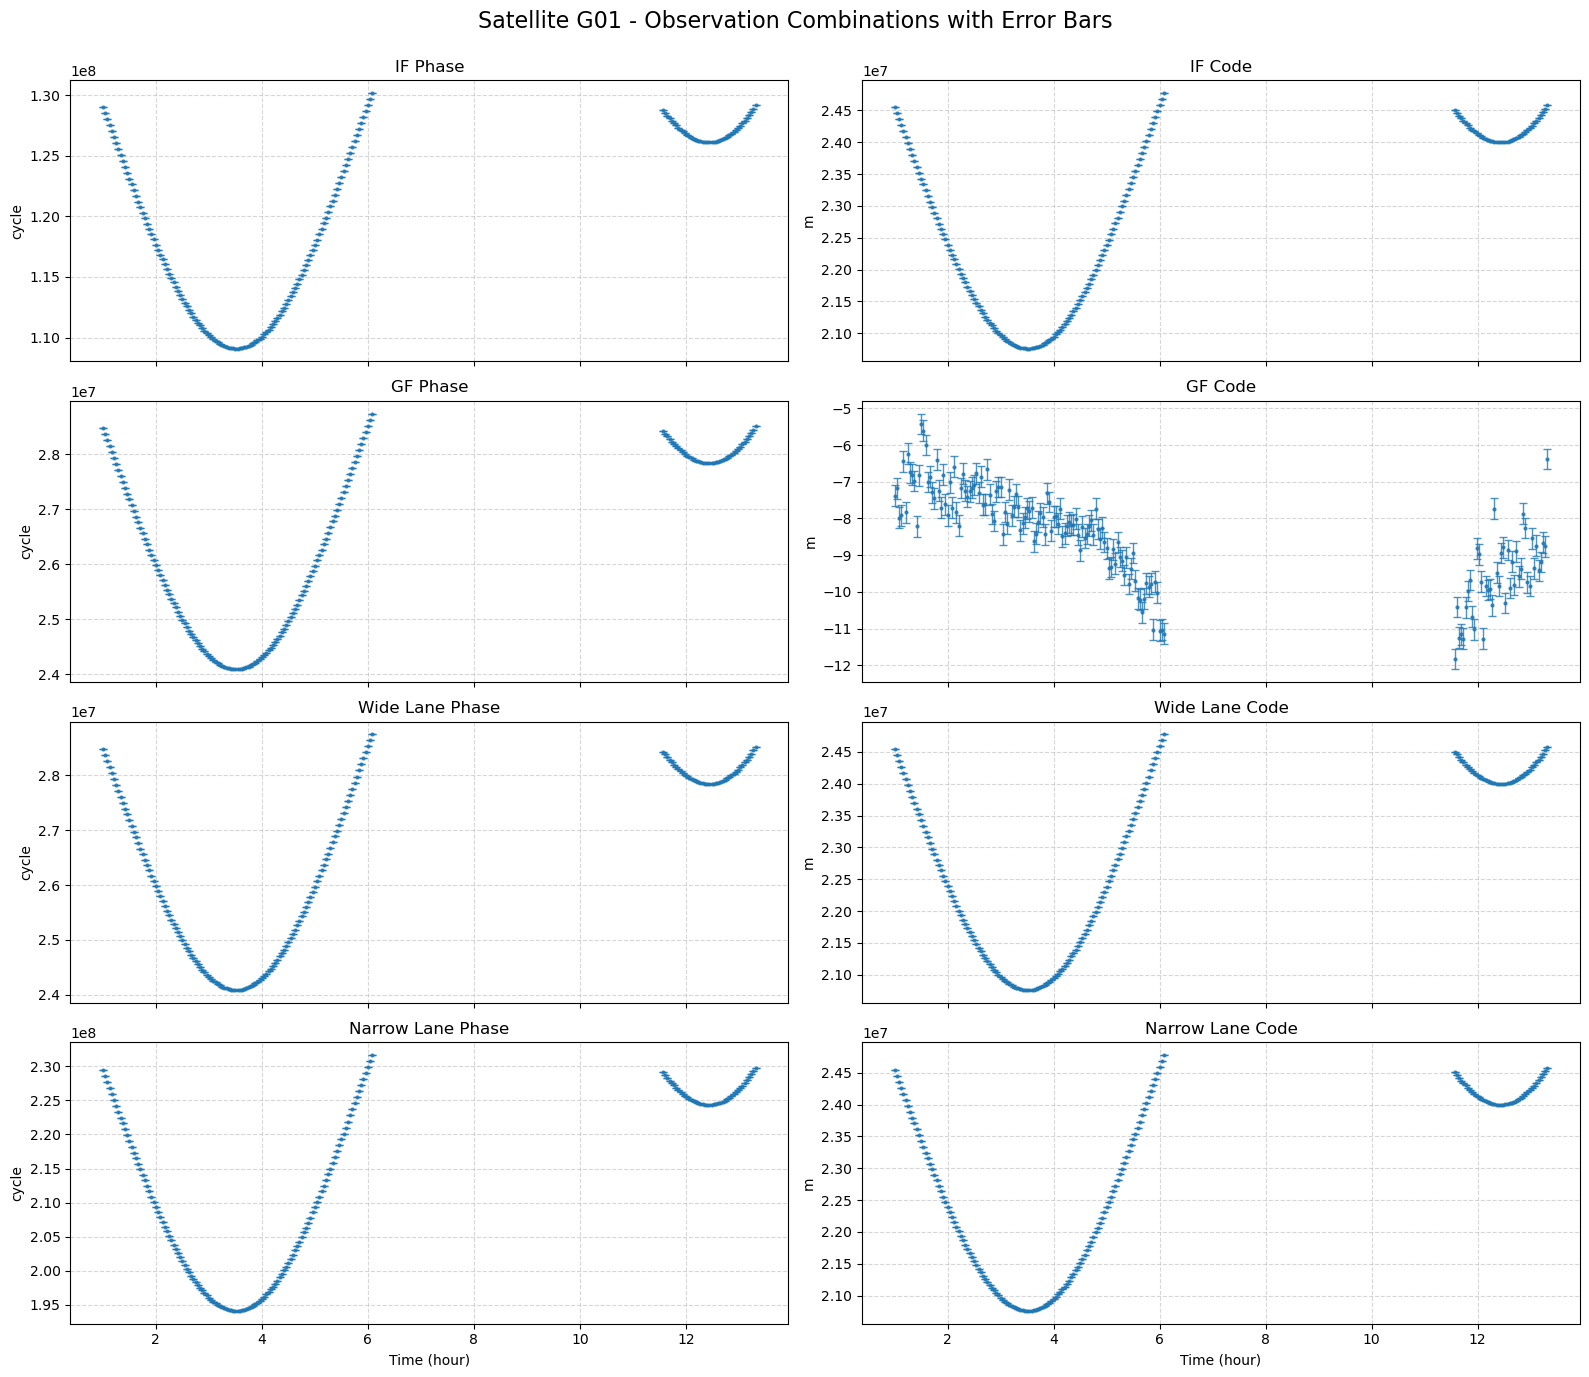

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import georinex as gr

# --- 1. Constants ---
c = 299792458.0
f1, f2 = 1575.42e6, 1227.60e6
lambda1, lambda2 = c / f1, c / f2

# دقت مشاهدات اولیه (فرضیات مسئله)
sigma_code = 0.2          # متر
sigma_phase = 0.02        # سیکل

# --- 2. Load Data ---
obs = gr.load('tehn0600.17o')
sv_target = 'G01'

# استخراج داده‌ها و حذف مقادیر خالی (NaN)
L1 = obs.sel(sv=sv_target)['L1'].dropna(dim='time')
L2 = obs.sel(sv=sv_target)['L2'].dropna(dim='time')
C1 = obs.sel(sv=sv_target)['C1'].dropna(dim='time') 
C2 = obs.sel(sv=sv_target)['P2'].dropna(dim='time')

# پیدا کردن زمان‌های مشترک برای هر 4 مشاهده
common_times = np.intersect1d(L1.time.values, L2.time.values)
common_times = np.intersect1d(common_times, C1.time.values)
common_times = np.intersect1d(common_times, C2.time.values)

# تبدیل زمان به ساعت (از ابتدای رصد) برای محور افقی
time_hours = (common_times - common_times[0]).astype('timedelta64[s]').astype(float) / 3600.0 + 1.0

# استخراج مقادیر هم‌زمان
l1_vals = L1.sel(time=common_times).values
l2_vals = L2.sel(time=common_times).values
c1_vals = C1.sel(time=common_times).values
c2_vals = C2.sel(time=common_times).values

# --- 3. Compute Combinations ---
# مقادیر فاز بر حسب سیکل و کد بر حسب متر محاسبه می‌شوند

# Iono-Free (IF)
# ضرایب فاز IF (بر حسب سیکل)
c1_if_ph, c2_if_ph = (f1**2)/(f1**2 - f2**2), -(f1*f2)/(f1**2 - f2**2)
if_phase = c1_if_ph * l1_vals + c2_if_ph * l2_vals
sigma_if_ph = np.sqrt((c1_if_ph * sigma_phase)**2 + (c2_if_ph * sigma_phase)**2)

# ضرایب کد IF (بر حسب متر)
c1_if_cd, c2_if_cd = (f1**2)/(f1**2 - f2**2), -(f2**2)/(f1**2 - f2**2)
if_code = c1_if_cd * c1_vals + c2_if_cd * c2_vals
sigma_if_cd = np.sqrt((c1_if_cd * sigma_code)**2 + (c2_if_cd * sigma_code)**2)

# Geometry-Free (GF)
gf_phase = l1_vals - l2_vals
sigma_gf_ph = np.sqrt(sigma_phase**2 + sigma_phase**2)

gf_code = c1_vals - c2_vals
sigma_gf_cd = np.sqrt(sigma_code**2 + sigma_code**2)

# Wide-Lane (WL)
wl_phase = l1_vals - l2_vals
sigma_wl_ph = np.sqrt(sigma_phase**2 + sigma_phase**2)

c1_wl_cd, c2_wl_cd = f1/(f1 + f2), f2/(f1 + f2)
wl_code = c1_wl_cd * c1_vals + c2_wl_cd * c2_vals
sigma_wl_cd = np.sqrt((c1_wl_cd * sigma_code)**2 + (c2_wl_cd * sigma_code)**2)

# Narrow-Lane (NL)
nl_phase = l1_vals + l2_vals
sigma_nl_ph = np.sqrt(sigma_phase**2 + sigma_phase**2)

c1_nl_cd, c2_nl_cd = f1/(f1 - f2), -f2/(f1 - f2)
nl_code = c1_nl_cd * c1_vals + c2_nl_cd * c2_vals
sigma_nl_cd = np.sqrt((c1_nl_cd * sigma_code)**2 + (c2_nl_cd * sigma_code)**2)

# --- 4. Plotting ---
fig, axs = plt.subplots(4, 2, figsize=(16, 14), sharex=True)
fig.suptitle(f'Satellite {sv_target} - Observation Combinations with Error Bars', fontsize=16)

# تنظیمات عمومی رسم (برای خلوت شدن نمودار و دیده شدن ارور بارها، از هر N نقطه یکی رسم می‌شود)
step = 5 
plot_kwargs = {'fmt': '.', 'markersize': 4, 'capsize': 3, 'elinewidth': 1, 'alpha': 0.8}

# --- ردیف 1: IF ---
axs[0, 0].errorbar(time_hours[::step], if_phase[::step], yerr=sigma_if_ph, **plot_kwargs)
axs[0, 0].set_title('IF Phase')
axs[0, 0].set_ylabel('cycle')
axs[0, 0].grid(True, linestyle='--', alpha=0.5)

axs[0, 1].errorbar(time_hours[::step], if_code[::step], yerr=sigma_if_cd, **plot_kwargs)
axs[0, 1].set_title('IF Code')
axs[0, 1].set_ylabel('m')
axs[0, 1].grid(True, linestyle='--', alpha=0.5)

# --- ردیف 2: GF ---
axs[1, 0].errorbar(time_hours[::step], gf_phase[::step], yerr=sigma_gf_ph, **plot_kwargs)
axs[1, 0].set_title('GF Phase')
axs[1, 0].set_ylabel('cycle')
axs[1, 0].grid(True, linestyle='--', alpha=0.5)

axs[1, 1].errorbar(time_hours[::step], gf_code[::step], yerr=sigma_gf_cd, **plot_kwargs)
axs[1, 1].set_title('GF Code')
axs[1, 1].set_ylabel('m')
axs[1, 1].grid(True, linestyle='--', alpha=0.5)

# --- ردیف 3: Wide Lane ---
axs[2, 0].errorbar(time_hours[::step], wl_phase[::step], yerr=sigma_wl_ph, **plot_kwargs)
axs[2, 0].set_title('Wide Lane Phase')
axs[2, 0].set_ylabel('cycle')
axs[2, 0].grid(True, linestyle='--', alpha=0.5)

axs[2, 1].errorbar(time_hours[::step], wl_code[::step], yerr=sigma_wl_cd, **plot_kwargs)
axs[2, 1].set_title('Wide Lane Code')
axs[2, 1].set_ylabel('m')
axs[2, 1].grid(True, linestyle='--', alpha=0.5)

# --- ردیف 4: Narrow Lane ---
axs[3, 0].errorbar(time_hours[::step], nl_phase[::step], yerr=sigma_nl_ph, **plot_kwargs)
axs[3, 0].set_title('Narrow Lane Phase')
axs[3, 0].set_ylabel('cycle')
axs[3, 0].set_xlabel('Time (hour)')
axs[3, 0].grid(True, linestyle='--', alpha=0.5)

axs[3, 1].errorbar(time_hours[::step], nl_code[::step], yerr=sigma_nl_cd, **plot_kwargs)
axs[3, 1].set_title('Narrow Lane Code')
axs[3, 1].set_ylabel('m')
axs[3, 1].set_xlabel('Time (hour)')
axs[3, 1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.show()
